In [ ]:
import numpy as np
import matplotlib.pyplot as plt

BUDGET = 1_000_000

def fee(vol_of_product: float, budget: float) -> float:
    return (vol_of_product / 100) * (vol_of_product / 100) * budget

def calc_pnl(vol_of_product: float, expected_return: float) -> float:
    gross=BUDGET * (vol_of_product/100) * expected_return
    return gross-fee(vol_of_product, BUDGET)


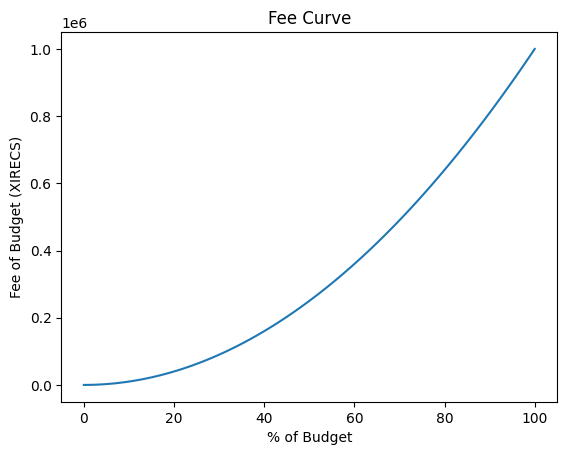

In [ ]:
fee_dist = [fee(i, BUDGET) for i in range(0,101)]
plt.plot([i for i in range(0, 101)], fee_dist)
plt.title("Fee Curve")
plt.ylabel("Fee of Budget (XIRECS)")
plt.xlabel("% of Budget")
plt.show()

In [ ]:
'''
    NEWSPAPER ANALYSIS

    BEST LONGS RANKED:

    Thermalite core - Surge / Strong forecast
    Scoria Paste - Crucial Utility. Social media influencer recommending to "stockpile" on it.
    Sulfur - Index inclusion means more slow purchasing
    Magma Ink - Hot drop. Super recent hype, but hype probably died down
    Volcanic Incense - Hype + Momentum, but might be risky

    BEST SHORTS RANKED:
    Lava Cake - Health crisis
    Pyroflex -

'''

In [26]:
PRODUCTS = {
    "OBSIDIAN_CULTRY": { # supply shock + chemical breach and contamination. pretty sure its negative
        "EXPECTED_RETURN": -0.2,
        "WEIGHT": 0.1
    },
    "PYROFLEX_CELLS": { # for sure going to go down, but how much
        "EXPECTED_RETURN": -0.2,
        "WEIGHT": 0.15
    },
    "THERMALITE_CORE": {
        "EXPECTED_RETURN": 0.3, # VERY CONDIFENT GOING UP
        "WEIGHT": 0.2
    },
    "LAVA_CAKE": { # MOST CONFIDENT GOING DOWN
        "EXPECTED_RETURN": -0.6,
        "WEIGHT": 0.3
    },
    "MAGMA_INK": { # hype is over
        "EXPECTED_RETURN": 0,
        "WEIGHT": 0
    },
    "SCORIA_PASTE": {
        "EXPECTED_RETURN": 0.2, # high utility + hype
        "WEIGHT": 0.1
    },
    "ASHES_OF_THE_PHOENIX": {
        "EXPECTED_RETURN": 0, # super uncertain
        "WEIGHT": 0
    },
    "VOLCANIC_INCENSE": {
        "EXPECTED_RETURN": 0.1, # A bit suspicious about the main buyer, so weigh with caution
        "WEIGHT": 0.05
    },
    "SULFUR_REACTOR": {
        "EXPECTED_RETURN": 0.2, # for sure going to go up, but how much?
        "WEIGHT": 0.15
    }
}


In [27]:
def sim_product(products, product_name: str) -> int:
    if products[product_name]["EXPECTED_RETURN"] < 0:
       side = -1
    else:
       side = 1

    upper_bound = int(products[product_name]["WEIGHT"]*100)
    all_pnl = []
    best_pnl = (0,0)
    for i in range(0, upper_bound+1):
        curr_pnl=calc_pnl(i*side, products[product_name]["EXPECTED_RETURN"])
        if curr_pnl>best_pnl[0]:
          best_pnl = (curr_pnl, i*side)
        all_pnl.append(curr_pnl)
    return all_pnl, best_pnl

Best PNL for OBSIDIAN_CULTRY was 9999.999999999998 XIRECS @ -10 VOLUME


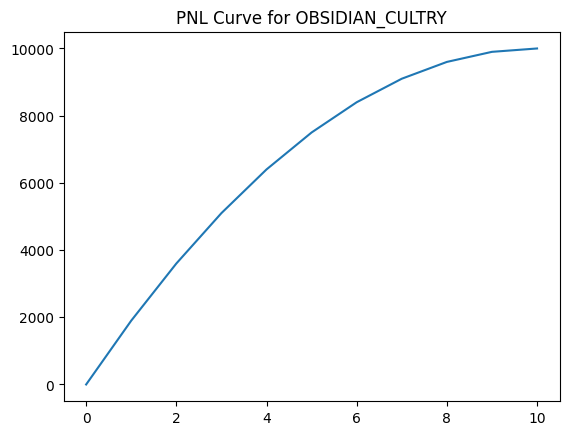

Best PNL for PYROFLEX_CELLS was 9999.999999999998 XIRECS @ -10 VOLUME


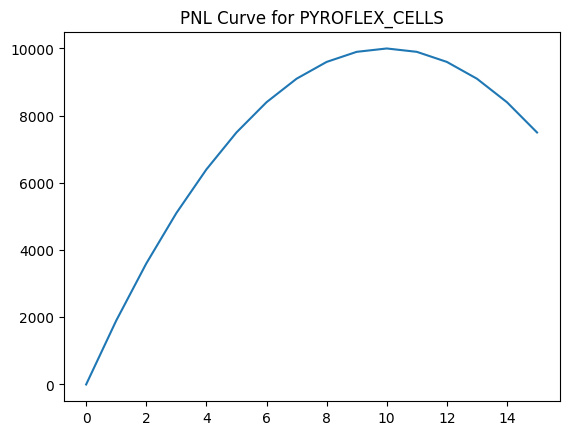

Best PNL for THERMALITE_CORE was 22500.0 XIRECS @ 15 VOLUME


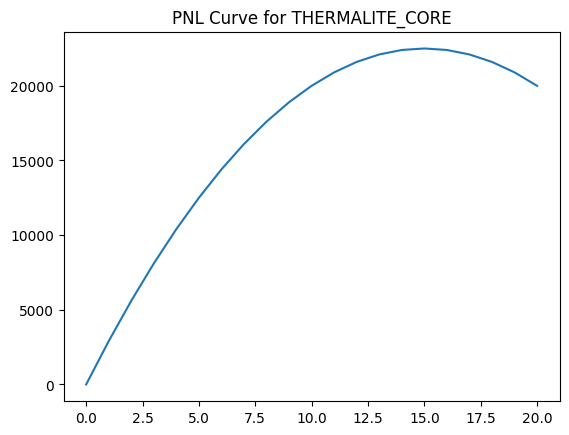

Best PNL for LAVA_CAKE was 90000.0 XIRECS @ -30 VOLUME


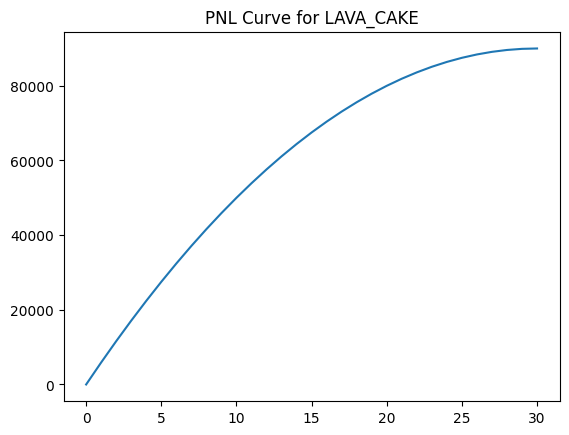

Best PNL for MAGMA_INK was 0 XIRECS @ 0 VOLUME


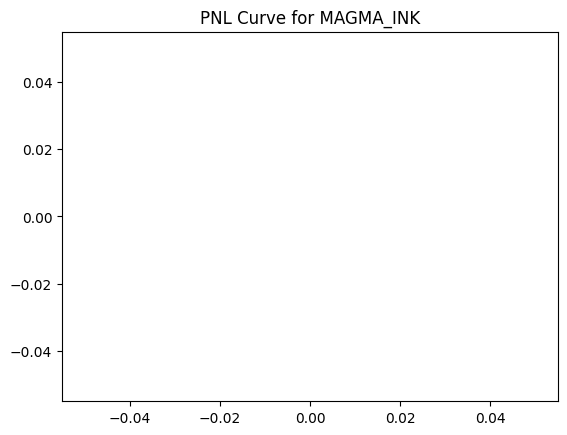

Best PNL for SCORIA_PASTE was 9999.999999999998 XIRECS @ 10 VOLUME


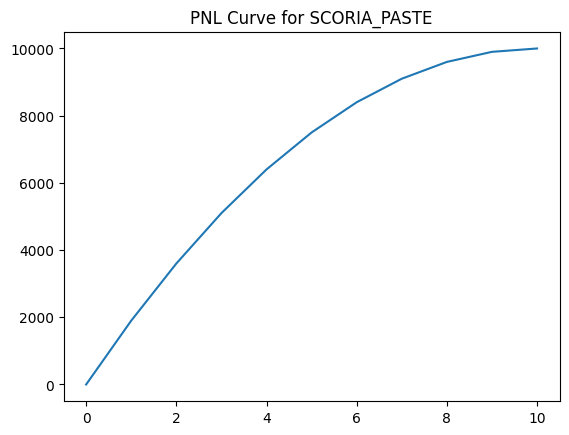

Best PNL for ASHES_OF_THE_PHOENIX was 0 XIRECS @ 0 VOLUME


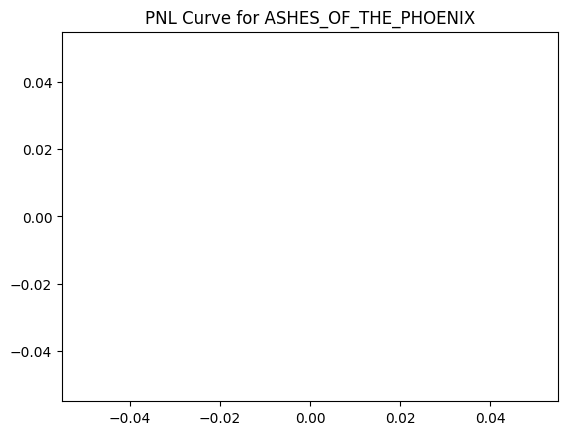

Best PNL for VOLCANIC_INCENSE was 2499.9999999999995 XIRECS @ 5 VOLUME


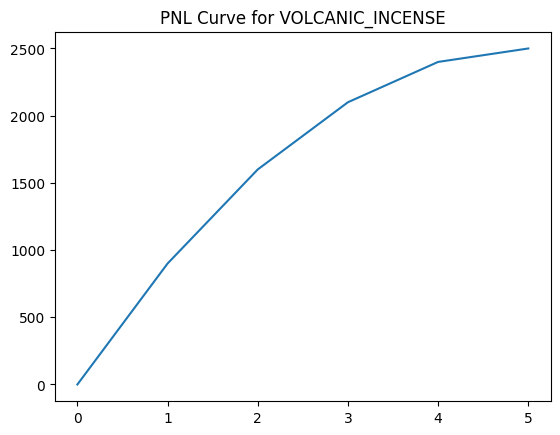

Best PNL for SULFUR_REACTOR was 9999.999999999998 XIRECS @ 10 VOLUME


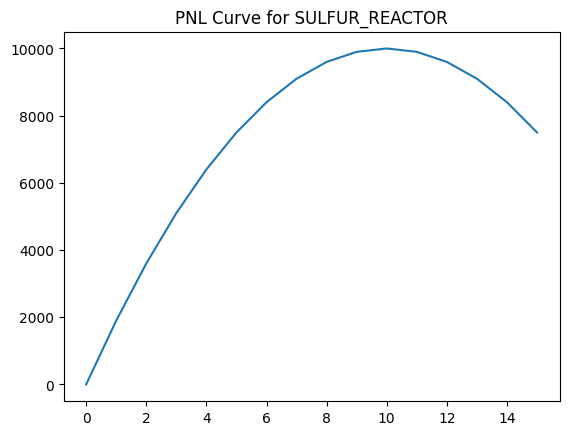

In [28]:
best_trades=[]
total_pnl = 0
inventory_used = 0
for product in PRODUCTS:
    pnls, b_pnl = sim_product(PRODUCTS, product)
    best_trades.append(b_pnl)
    print("Best PNL for " + product + " was " + str(b_pnl[0]) + " XIRECS @ " + str(b_pnl[1]) + " VOLUME")
    plt.title("PNL Curve for " + product)
    total_pnl += b_pnl[0]
    inventory_used += abs(b_pnl[1])
    plt.plot(pnls)
    plt.show()

In [29]:
print(total_pnl)

155000.0


In [30]:
print(inventory_used)

90
